# Official HEC-HMS Guide Mirror: Basic Model Setup

Official guide: https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/basic-model-setup

This notebook mirrors the Basic Model Setup guide at a programmatic level: extract an HMS sample project, inspect the core components, select a run, compute it headlessly, and plot the resulting outlet hydrograph from DSS output.

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

logging.disable(logging.CRITICAL)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "hms_commander").is_dir() and (candidate / "examples").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
WORK_ROOT = REPO_ROOT / "examples" / "working" / "clb238_guides"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
HMS_VERSION = "4.13"

from hms_commander import HmsExamples, HmsPrj

available_versions = HmsExamples.list_versions()
if HMS_VERSION not in available_versions:
    HMS_VERSION = available_versions[0]
HMS_EXE = HmsExamples.get_hms_exe(HMS_VERSION)


def init_sample_project(project_name, notebook_key, overwrite=True):
    project_path = HmsExamples.extract_project(
        project_name,
        version=HMS_VERSION,
        output_path=WORK_ROOT / notebook_key,
        overwrite=overwrite,
    )
    project = HmsPrj()
    project.initialize(project_path, hms_exe_path=HMS_EXE)
    return project, project_path

In [2]:
from hms_commander import HmsCmdr, HmsDss

project, project_path = init_sample_project("castro", "101_basic_model_setup")
run_name = "Current"
config = project.get_run_configuration(run_name)

component_counts = pd.DataFrame([
    {"component": "Basin models", "count": len(project.basin_df)},
    {"component": "Meteorologic models", "count": len(project.met_df)},
    {"component": "Control specs", "count": len(project.control_df)},
    {"component": "Simulation runs", "count": len(project.run_df)},
    {"component": "Time-series gages", "count": len(project.gage_df)},
])
assert component_counts["count"].sum() > 0

run_summary = pd.DataFrame([{
    "run_name": config["run_name"],
    "basin_model": config["basin_name"],
    "met_model": config["met_name"],
    "control_spec": config["control_name"],
    "output_dss": config["dss_file"],
    "basin_area_sqmi": round(float(config["basin_area"]), 2),
    "control_start": config["control_start"],
    "control_end": config["control_end"],
    "interval_minutes": int(config["control_interval_minutes"]),
}])

display(component_counts)
display(run_summary)

,component,count
0,Basin models,2
1,Meteorologic models,1
2,Control specs,1
3,Simulation runs,2
4,Time-series gages,2


,run_name,basin_model,met_model,control_spec,output_dss,basin_area_sqmi,control_start,control_end,interval_minutes
0,Current,Castro 1,GageWts,Jan73,Current.dss,40.51,1973-01-16 03:00:00,1973-01-16 12:55:00,5


In [3]:
success = HmsCmdr.compute_run(
    run_name,
    hms_object=project,
    timeout=120,
    save_project=False,
    max_memory="2G",
)
assert success, f"HMS compute failed for run {run_name}"

dss_file = project_path / config["dss_file"]
expected_outputs = [
    dss_file,
    project_path / f"{run_name}.log",
    project_path / f"{run_name}.out",
]
output_check = pd.DataFrame([
    {
        "file": path.name,
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 1) if path.exists() else 0.0,
    }
    for path in expected_outputs
])
assert output_check.loc[output_check["file"] == config["dss_file"], "exists"].iloc[0]

catalog = HmsDss.get_catalog(dss_file)
outlet_path = next(
    path for path in catalog
    if "//OUTLET/FLOW/" in path.upper() and f"RUN:{run_name.upper()}" in path.upper()
)
outlet_flow = HmsDss.read_timeseries(dss_file, outlet_path)
peak_idx = outlet_flow["value"].idxmax()
hydrograph_summary = pd.DataFrame([{
    "element": "Outlet",
    "dss_path": outlet_path,
    "time_steps": len(outlet_flow),
    "peak_cfs": round(float(outlet_flow.loc[peak_idx, "value"]), 1),
    "peak_time": peak_idx,
    "total_points": len(catalog),
}])

display(output_check)
display(hydrograph_summary)

Configuring Java VM for DSS operations...
[OK] Java VM configured


,file,exists,size_kb
0,Current.dss,True,267.0
1,Current.log,True,2.6
2,Current.out,True,920.8


,element,dss_path,time_steps,peak_cfs,peak_time,total_points
0,Outlet,//OUTLET/FLOW/16JAN1973/5MIN/RUN:CURRENT/,120,540.3,1973-01-16 06:55:00,84


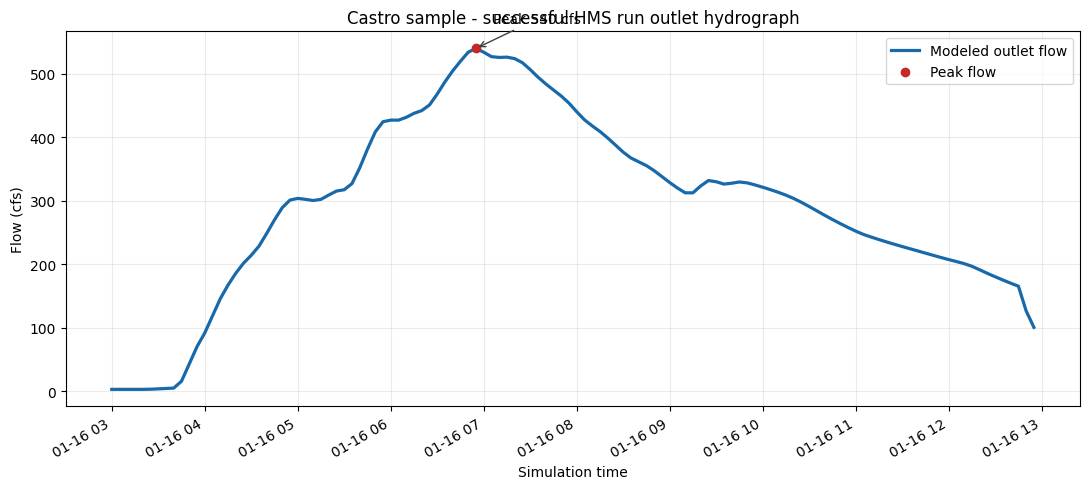

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(outlet_flow.index, outlet_flow["value"], color="#1769aa", linewidth=2.3, label="Modeled outlet flow")
ax.scatter([peak_idx], [outlet_flow.loc[peak_idx, "value"]], color="#c62828", zorder=3, label="Peak flow")
ax.annotate(
    f"Peak {outlet_flow.loc[peak_idx, 'value']:.0f} cfs",
    xy=(peak_idx, outlet_flow.loc[peak_idx, "value"]),
    xytext=(12, 18),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#424242"},
)
ax.set_title("Castro sample - successful HMS run outlet hydrograph")
ax.set_xlabel("Simulation time")
ax.set_ylabel("Flow (cfs)")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Coverage Notes

The official GUI guide introduces basin models, meteorologic models, control specifications, simulation runs, compute, and results review. This notebook exercises the same bridge through hms-commander and confirms the run by plotting the DSS outlet hydrograph.